In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
antiguedad = pd.read_csv("src/result/antiguitat_distritos.csv")
poblacion = pd.read_csv("src/result/poblacion_distritos.csv")
renta = pd.read_csv("src/result/renta_distritos.csv")
tipos = pd.read_csv("src/result/tipus_vehicle_distritos.csv")

In [9]:
df_final = (poblacion.merge(renta, on="Nom_Districte", how="left").merge(tipos, on="Nom_Districte", how="left"))

In [10]:
df_final

,Unnamed: 0,Nom_Districte,Valor,Import_Euros,Tipus_Propulsio,Unidades
0,0,Ciutat Vella,101864,17033.31,Diesel,11157
1,0,Ciutat Vella,101864,17033.31,Eléctrica,6433
2,0,Ciutat Vella,101864,17033.31,Gasolina,25402
3,0,Ciutat Vella,101864,17033.31,Hibrido,1987
4,0,Ciutat Vella,101864,17033.31,No consta,69
5,0,Ciutat Vella,101864,17033.31,Otros,606
6,1,Eixample,245773,26005.30,Diesel,34007
7,1,Eixample,245773,26005.30,Eléctrica,2195
8,1,Eixample,245773,26005.30,Gasolina,84176
9,1,Eixample,245773,26005.30,Hibrido,9864


In [43]:
tipos = pd.DataFrame(tipos)
tipos

,Nom_Districte,Nom_Barri,Tipus_Propulsio,Unidades
0,Ciutat Vella,"Sant Pere, Santa Caterina i la Ribera",Diesel,2035
1,Ciutat Vella,"Sant Pere, Santa Caterina i la Ribera",Eléctrica,4084
2,Ciutat Vella,"Sant Pere, Santa Caterina i la Ribera",Gasolina,7177
3,Ciutat Vella,"Sant Pere, Santa Caterina i la Ribera",Hibrido,536
4,Ciutat Vella,"Sant Pere, Santa Caterina i la Ribera",No consta,17
...,...,...,...,...
428,Sarrià-St. Gervasi,les Tres Torres,Eléctrica,306
429,Sarrià-St. Gervasi,les Tres Torres,Gasolina,9038
430,Sarrià-St. Gervasi,les Tres Torres,Hibrido,841
431,Sarrià-St. Gervasi,les Tres Torres,No consta,14


In [4]:
df = poblacion.merge(renta, how="left", on=["Nom_Districte", "Nom_Barri"])
df

,Unnamed: 0,Nom_Districte,Nom_Barri,Valor,Import_Euros
0,0,Ciutat Vella,"Sant Pere, Santa Caterina i la Ribera",20413,19655.15
1,1,Ciutat Vella,el Barri Gòtic,25609,18668.11
2,2,Ciutat Vella,el Raval,42429,14221.14
3,3,Ciutat Vella,la Barceloneta,13413,17965.91
4,4,Eixample,Sant Antoni,34703,23587.50
...,...,...,...,...,...
68,68,Sarrià-St. Gervasi,Sant Gervasi - la Bonanova,21935,36110.22
69,69,Sarrià-St. Gervasi,Sarrià,20240,35446.38
70,70,Sarrià-St. Gervasi,"Vallvidrera, el Tibidabo i les Planes",3922,29594.67
71,71,Sarrià-St. Gervasi,el Putxet i el Farró,25838,29461.42


In [5]:
df = df.drop("Unnamed: 0", axis=1)

In [71]:
df2

,Nom_Districte,Nom_Barri,Valor,Import_Euros
0,Ciutat Vella,"Sant Pere, Santa Caterina i la Ribera",20413,19655.15
1,Ciutat Vella,el Barri Gòtic,25609,18668.11
2,Ciutat Vella,el Raval,42429,14221.14
3,Ciutat Vella,la Barceloneta,13413,17965.91
4,Eixample,Sant Antoni,34703,23587.50
...,...,...,...,...
68,Sarrià-St. Gervasi,Sant Gervasi - la Bonanova,21935,36110.22
69,Sarrià-St. Gervasi,Sarrià,20240,35446.38
70,Sarrià-St. Gervasi,"Vallvidrera, el Tibidabo i les Planes",3922,29594.67
71,Sarrià-St. Gervasi,el Putxet i el Farró,25838,29461.42


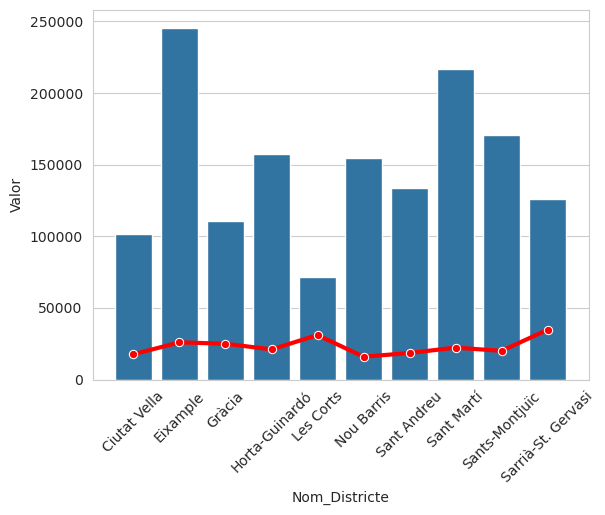

In [77]:
## Nº total de población por distritos

sns.barplot(df2,x="Nom_Districte",y="Valor", errorbar=None, estimator=sum )
plt.xticks(rotation=45)
sns.lineplot(data=df2, x="Nom_Districte", y="Import_Euros", 
             marker="o", color="red", linewidth=3, errorbar=None)
plt.show()

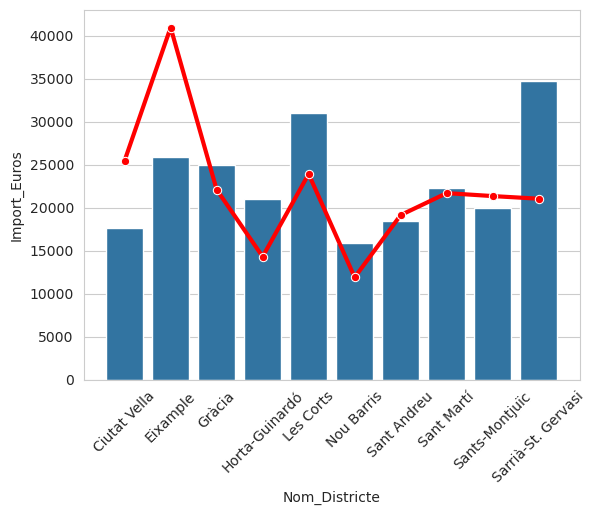

In [79]:
sns.barplot(df,x="Nom_Districte",y="Import_Euros", errorbar=None)
sns.lineplot(data=df, x="Nom_Districte", y="Valor",
             marker="o", color="red", linewidth=3, errorbar=None)
plt.xticks(rotation=45)
plt.show()

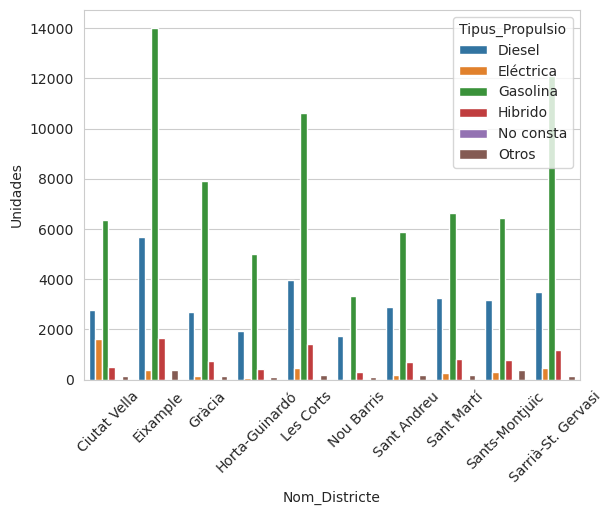

In [80]:
sns.barplot(data=tipos, x="Nom_Districte", y="Unidades", hue="Tipus_Propulsio", errorbar=None)
plt.xticks(rotation=45)
plt.show()

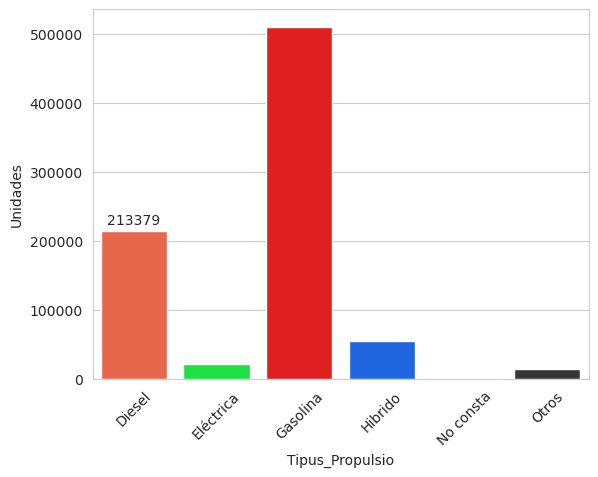

In [103]:
colores_personalizados = {
    "Diesel": "#FF5733",
    "Eléctrica": "#00FF2F",
    "Gasolina": "#FF0000",
    "Hibrido": "#005EFF",
    "No consta": "#FF0FBF",
    "Otros": "#373737"
}


sns.set_style("whitegrid")
ax = sns.barplot(data=tipos, x="Tipus_Propulsio", hue="Tipus_Propulsio", palette=colores_personalizados, y="Unidades", errorbar=None, estimator=sum)
ax.bar_label(ax.containers[0], padding=3, fmt='%.0f')
plt.xticks(rotation=45)
plt.show()

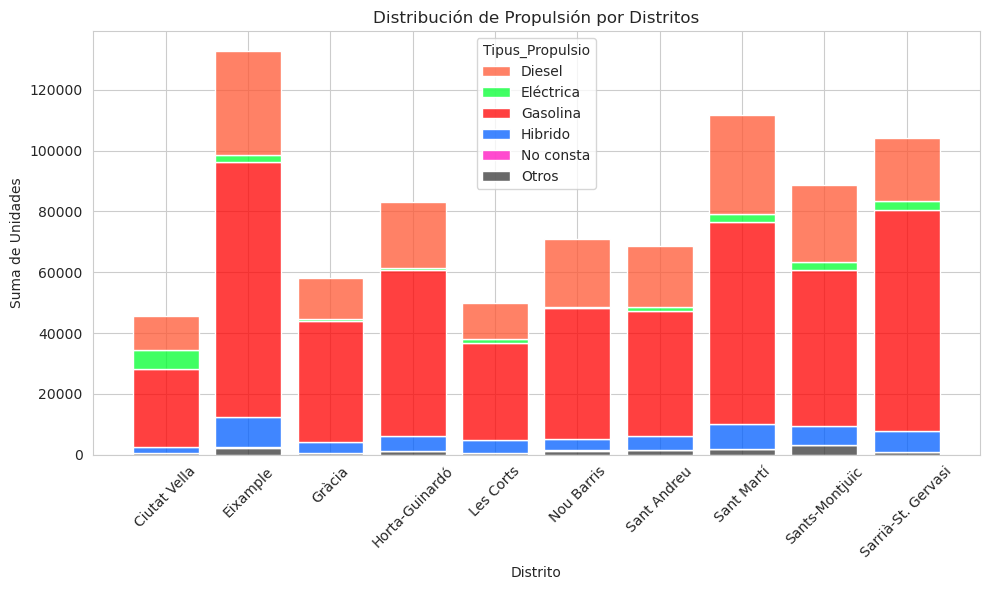

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(
    data=tipos,
    x='Nom_Districte',
    weights='Unidades', # Aquí indicas que la altura de la barra es el valor de "Unidades"
    hue='Tipus_Propulsio',
    multiple='stack',   # Esto es lo que pone todos en la misma columna
    palette=colores_personalizados,
    shrink=0.8          # Para que las barras no se peguen entre sí
)

plt.title("Distribución de Propulsión por Distritos")
plt.xticks(rotation=45)
plt.xlabel("Distrito")
plt.ylabel("Suma de Unidades")
plt.tight_layout()
plt.show()



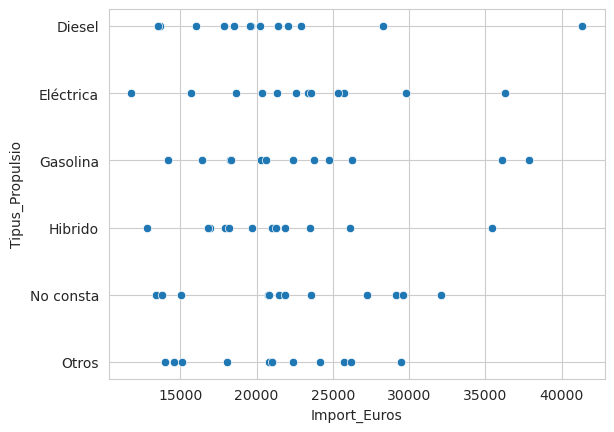

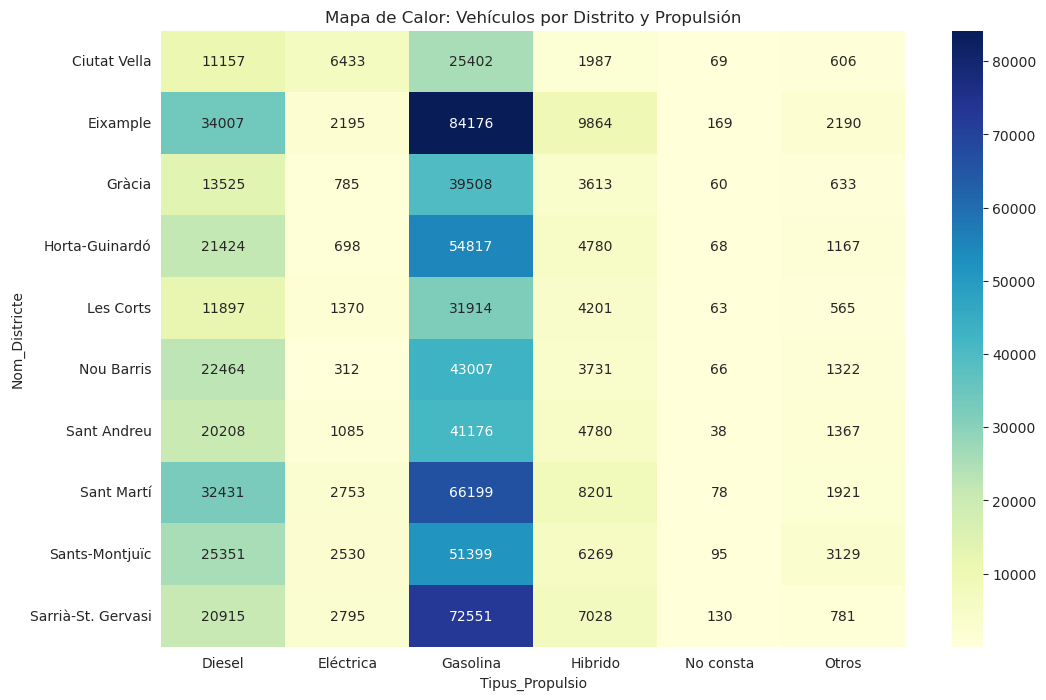

In [109]:
df_pivot = tipos.pivot_table(
    index='Nom_Districte', 
    columns='Tipus_Propulsio', 
    values='Unidades', 
    aggfunc='sum'
)

# 2. Dibujar el Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df_pivot, annot=True, fmt=".0f", cmap="YlGnBu")

plt.title('Mapa de Calor: Vehículos por Distrito y Propulsión')
plt.show()